<div style='border-top:1px solid #68C1EE; border-bottom: 1px solid #68C1EE; padding: 10px'>


<h1 style='color:#147EB3'><b>Milestone 4</b></h1>


<h2 style='color:#68C1EE' > <i> Baseline Model, Pipeline Development, and TF Meeting</i></h2>

<h3 style='color:#D33D17' ><b style='color:#96290D'>Project Group #2:&nbsp;</b><i> Max Bahar, Mila Ivanovska, Stefan Chu, Ted McCulloch</i></h3>

</div>


In [ ]:
# imports
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# utilities
import utils.visualization as viz

#### Table of Contents 

1. [Introduction and Problem Statement](#1-intro)

    1.1 [Background](#1-1-background)

    1.2 [Research Question](#1-2-research-question)

2. [Comprehensive EDA](#2-eda-review)

    2.1 [Data Summary](#2-1-data-summary) 

    2.2 [Key Findings](#2-2-key-findings)

3. [Baseline Model](#3-baseline-model) 

    3.1 [Baseline Model Description](#3-1-baseline-model-description)

    3.2 [Training Process](#3-2-training)

    3.3 [Preliminary Results](#3-3-preliminary-results)

4.  [Results Interpretation and Analysis](#4-results)

    4.1 [Baseline Model Results](#4-1-baseline-results)

    4.2 [Pivot to Time-dependent Modeling](#4-2-time-modeling)

5. [Final Model Setup](#5-final-model)

    [References](#references)

<div style='border-top:1px solid #68C1EE; border-bottom: 1px solid #68C1EE; padding: 10px'>
<h2 style='color:#147EB3'>1. Introduction and Problem Statement <a class="anchor" id="1-intro"></a></h2>
</div>

### 1.1 Background <a class="anchor" id="1-1-background"></a>

Currently, there are around 30,000 publicly cataloged objects in Earth's orbit. In reality, the number is likely much higher, as 1) not every piece of debris in orbit has a known position or identification number,  2) not every payload is publicly disclosed by the government of origin, and  3) different organizations report varying figures.

Traditionally, space objects are classified into three categories:

1. **Payloads**: Functional spacecraft or satellites launched into space to perform specific missions, such as communication, navigation, or research.

2. **Rocket Bodies**: Parts of launch vehicles (e.g., stages) that delivered payloads to orbit but remain in space as non-operational objects.

3. **Debris**: Non-functional fragments or objects in space, including pieces from collisions, explosions, or decommissioned satellites, that no longer serve any purpose.

While all objects are subject to the same orbital perturbations, the nature of each object type should produce identifiable patterns in their orbital elements. For example, active payloads will conduct station-keeping maneuvers to maintain their desired orbits. Geostationary satellites, for instance, have orbital periods of nearly exactly 1,440 minutes—matching Earth's rotation. However, if they stop performing station-keeping maneuvers, their orbits will begin to drift due to various perturbative forces (gravity, drag, radiation pressure, solar activity, etc.). Likewise, although both are essentially space junk, debris and rocket bodies should also exhibit distinct orbital behaviors due to differences in their average size, mass, and origin.

### 1.2 Research Question <a class="anchor" id="1-2-research-question"></a>

**Given a history of orbital states, can we predict with confidence any given object's type?**

Initially, we aimed to use two years of orbital data, removing time-dependent elements and identifiers to train our model to perform type classification. However, we are now pivoting to leverage the time dimension, using not a stationary set of elements, but rather a time-separated element histories as input to our three-type classification model. This pivot allows us to utilize more complex modeleling classes and techniques. Note: when considering states independently we will still exclude the epoch from our features but will likely incorporate it when grouping states by ID to encode order in the history. 

Our EDA has confirmed that there are differences in orbital elements amongst object types, which are most pronounced in inclination, eccentritiy, apogee, and argument of perigee. Moreover, by examing the correlations between our features, we identified several meaningful patterns (and noted the ones which were trivial/meaningless). 

<div style='border-top:1px solid #68C1EE; border-bottom: 1px solid #68C1EE; padding: 10px'>
<h2 style='color:#147EB3'>2.  Comprehensive EDA Review <a class="anchor" id="2-eda-review"></a></h2>
</div>

### 2.1 Data Summary <a class="anchor" id="2-1-data-summary"></a>

Our final data frame consists of data from:

1. Historical State information - collected from spacetrack on the 1st and 15th of each moth ranging from 03/15/2023 to 03/15/2025.

2. Satellite catalog (satcat) information - descriptive information about a satellite.

3. Calculated additional values - semi-major axis, apogee, perigee, and orbital regime need to be calculated using state information.

#### 2.1.1 Variables

The table below explains the response variable and predictors to be used in our modeling.

<table>
    <tr>
        <th>Feature</th> <th>Data Type</th> <th>Units</th> <th>Description</th>
    </tr>
    <tr>
        <td>TYPE (response)</td> <td>String/Enum</td> <td>-</td> <td>Type of object: payload, debris, rocket body</td>
    </tr>
    <tr>
        <td>INCL</td> <td>Float</td> <td>Degree</td> <td>Orbit inclination</td>
    </tr>
    <tr>
        <td>RAAN</td> <td>Float</td> <td>Degree</td> <td>Right Ascension of the Ascending Node - longitude of the point where the spacecraft crosses the equatorial plane</td>
    </tr>
    <tr>
        <td>ECC</td> <td>Float</td> <td>[0,1]</td> <td>Eccentricity - measure of how circular or elliptical an orbit is</td>
    </tr>
    <tr>
        <td>ARG_PER</td> <td>Float</td> <td>Degree</td> <td>Argument of perigee - rotation/orientation of orbit</td>
    </tr>
    <tr>
        <td>MEAN_MOTION</td> <td>Float</td> <td>Rev/Day</td> <td>Revolutions per day given orbit</td>
    </tr>
    <tr>
        <td>SMA_KM</td> <td>Float</td> <td>KM</td> <td>Semi-major axis - the distance from the center of an ellipse to the longer end of the ellipse</td>
    </tr>
    <tr>
        <td>APOGEE_KM</td> <td>Float</td> <td>KM</td> <td>Furthest orbit gets from Earth</td>
    </tr>
    <tr>
        <td>PERIGEE_KM</td> <td>Float</td> <td>KM</td> <td>Closest orbit gets from Earth</td>
    </tr>
    <tr>
        <td>MEAN_MOTION_1ST_DER</td> <td>Float</td> <td>Rev/Day<sup>2</sup></td> <td>Ballistic coefficient measure (angular velocity)</td>
    </tr>
    <tr>
        <td>MEAN_MOTION_2ND_DER</td> <td>Float</td> <td>Rev/Day<sup>3</sup></td> <td>2nd Derivative of Mean Motion (angular acceleration)</td>
    </tr>
    <tr>
        <td>B_STAR</td> <td>Float</td> <td>(radius of earth)<sup>-1</sup> </td> <td>Drag term or radiation pressure coefficient</td>
    </tr>
</table>

### 2.2 Key Findings <a class="anchor" id="2-2-key-findings"></a>

From our EDA, we were able to draw three main conclusions about the data which informed our feature engineering and data manipulation:

1. Mean anomaly is highly correlated with the epoch time and therefore likely does not contain meaningful information. We have decided to exclude it from our set of predictors.

2. We identified three meaningful patterns in the correlation matrix: (a) circular orbits have higher inclinations than elliptical orbits, (b) lower Earth orbits are more likely to be more inclined than higher Earth orbits, (c) lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity). 

3. When comparing semi-major axis, inclination, and eccentricity, we observe apparent differences in patterns across object types, even when holding orbital regime constant.

In [2]:
# Separate features into different categories
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] 
X_numerical_revised = X_numerical + ['MEAN_MOTION_2ND_DER', 'B_STAR']
response = 'TYPE'

# Fetch final dataframe
df_final = pd.read_csv('../data/large/final_df_v1.csv') # <-- Run Part 1 of DataConsolidation.ipynb to produce file

In [3]:
# Separate data into separate dataframes for each class
df_payload = df_final[df_final['TYPE'] == 'PAYLOAD']
df_rb = df_final[df_final['TYPE'] == 'ROCKET BODY']
df_debris = df_final[df_final['TYPE'] == 'DEBRIS']  

#### 2.2.1 Correlation of Variables

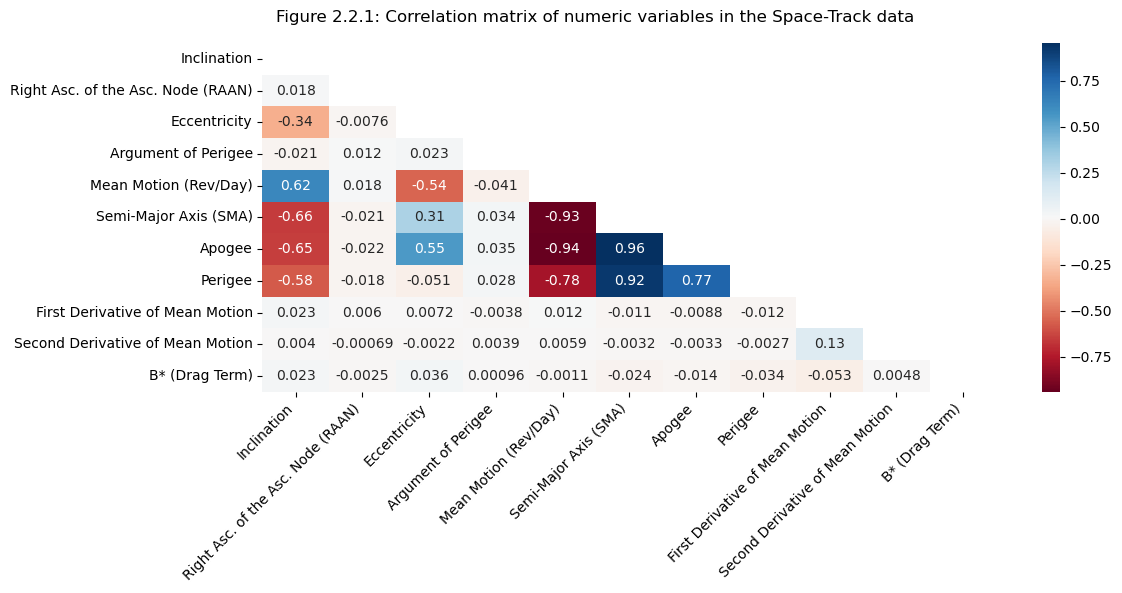

In [4]:
viz.plot_corr_matrix(df_final, X_numerical_revised, viz.pretty_column_names(), "Figure 2.2.1: Correlation matrix of numeric variables in the Space-Track data")

<table>
    <tbody>
        <tr>
            <th>Pattern A</th>
            <td>Circular orbits tend to have higher inclinations than elliptical orbits.</td>
        </tr>
        <tr>
            <th>Pattern B</th>
            <td>Lower Earth orbits are more likely to be more inclined than higher Earth orbits.</td>
        </tr>
        <tr>
            <th>Pattern C</th>
            <td>Lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Trivial</th>
            <td>Trivial comparisons amount to saying "larger orbits will be larger" or "smaller orbits will be smaller."</td>
        </tr>
    </tbody>
</table>

<p>These patterns are consistent with our understanding of orbital dynamics, and they hold between object types.</p>

#### 2.2.2 Distribution of Variables

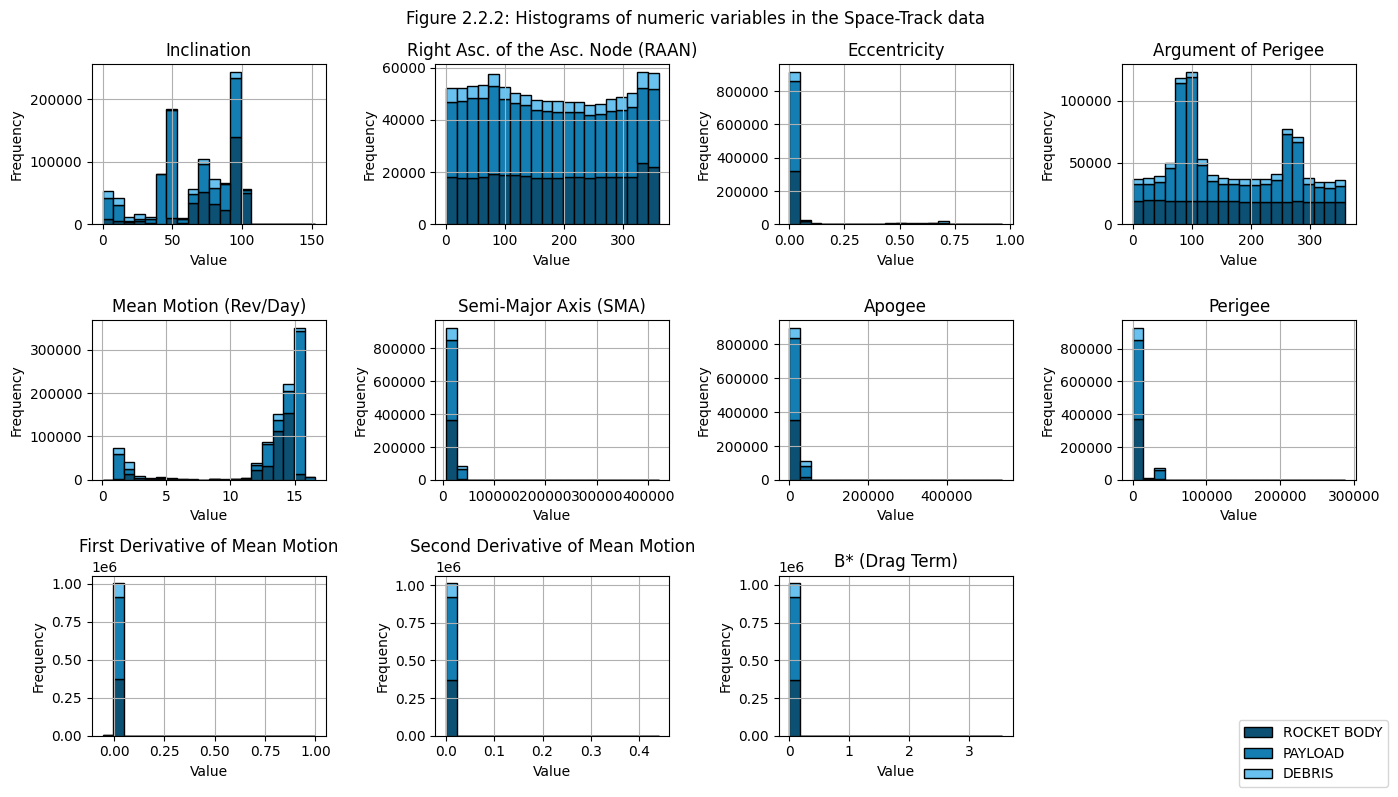

In [4]:
viz.plot_stacked_histograms([df_debris, df_payload,df_rb ], X_numerical_revised, viz.pretty_column_names(),"Figure 2.2.2: Histograms of numeric variables in the Space-Track data")

Figure 2.2.2: shows the distribution of our numerical variables--separated by object type. 

We found that there is a severe class imbalance between the 3 types of space objects. They made up 54.24%, 36.78%, and 8.97% of our dataset for Payload, Debris, and Rocket Body respectively. To remedy this, we first applied one-hot encoding on the categorical variables, "RCS", "IS_CURRENT", "REGIME", and "COUNTRY", to convert them into numerical values. By using one-hot encoding, we avoid implying a natural order between categories that do not. Next, we applied Synthetic Minority Oversampling Technique (SMOTE) to generate synthetic samples for the minority classes. This balances the class distribution, which has the effect of improving the model's performance on the minority classes, and reduces bias towards the majority class.

<div style='border-top:1px solid #68C1EE; border-bottom: 1px solid #68C1EE; padding: 10px'>
<h2 style='color:#147EB3'>3. Baseline Model Selection and Justification <a class="anchor" id="3-baseline-model"></a></h2>
</div>

### 3.1 Baseline Model Description <a class="anchor" id="3-1-baseline-model-description"></a>

As our baseline model, we chose a Feedforward Neural Network (FNN) with the following architecture:
- 3 hidden dense layers with 500, 250, and 50 nodes and the ReLU activation function.
- A dropout layer after each of the dense layers with a dropout rate of 0.15.
- An output dense layer with 3 units (the number of classes in `TYPE`) with the softmax activation function.

**Simplicity:**

We chose a FNN due to its relative simplicity in the context of 209B. We did our best to keep the model as simple as possible, choosing to omit any skip/residual connections, auxiliary blocks, or recurrent properties in the network architecture. The only form of regularization comes from the dropout layers in between each hidden dense layer. The model is relatively lightweight with a total of 142,953 trainable parameters and taking up 558.41 KB of memory.

**Interpretability:**

While neural networks are not the most interpretable model class, the simplicity of our FNN architecture helps limit the black-box nature typically associated with more complex architectures. With only three hidden layers with ReLU activations and the only source of regularization being dropout after each hidden layer, we retain a relatively direct relationship between input features and predictions.

**Relevance:**

We opted to neglect the time dimension of our data at this stage, simply passing in each state as a separate input to the model. By treating each state independently, this baseline measures how much of `TYPE` is predictable from a single 'snapshot' of features. In reality, multiple states may actually be from the same object at different points in time. We explore the time dependency of our modeling in the *"5. Final Model Pipeline Setup"* section further below. Any future gains from time-series models can be quantified as improvements over this static benchmark.

### 3.2 Training Process <a class="anchor" id="3-2-training"></a>

We preprocessed our data by applying `StandardScaler` to each predictor, centering each predictor's mean at 0 with standard deviation of 1. This prevents 'exploding gradients' caused by large numerical values, particularly for semi-major axis, apogee, and perigree.

To tackle class imbalance, we trained the baseline model on the modified data upsampled with SMOTE, increasing the number of observations from 1,011,052 to 1,645,200.

We decided to use 76.5% of the data as the training set, 13.5% as the validation set, and the remaining 10% as the test set. We stratified on the type of the object associated with the state to ensure that each split was representative of the overall distribution.

In [6]:
def preprocess_data(df_to_use, scaler, label_encoder, X_numerical, response, fit_scaler=True):

    X = df_to_use[X_numerical]
    y = df_to_use[response]
    y_encoded = label_encoder.fit_transform(y)
    if fit_scaler:
        scaler.fit(X)

    X_90, X_test, y_90, y_test = train_test_split(
        X, y_encoded,
        test_size=0.1,
        random_state=101,
        stratify=y_encoded
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_90, y_90,
        test_size=0.15,
        random_state=101,
        stratify=y_90
    )

    X_train = scaler.transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    return  X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler

For our baseline model training, we used the Adam optimizer with the default parameters of 0.001 learning rate, 0.9 exponential decay for the 1st momentum, and 0.999 exponential decay for the 2nd momentum.

The response variable is one-hot encoded, with the model minimizing categorical cross-entropy loss and tracking accuracy as an additional metric.

We chose to add early stopping with a patience of 5 (monitoring validation loss) in case of overfitting.

We also added a learning rate callback to reduce the learning rate by a factor of 0.5 (with a minimum learning rate of 1e-6) if validation loss does not improve after 3 epochs.

We chose a batch size of 32 to ensure the optimizer can get past local optima and trained for 25 epochs.

In [7]:
df_smote = pd.read_csv('../data/large/df_smote_v1.csv')  # <-- Run Part 2 of DataConsolidation.ipynb to produce file
label_encoder = LabelEncoder()
scaler = StandardScaler()
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler = preprocess_data(
    df_smote, scaler, label_encoder, X_numerical, response
)

# Baseline model parameters
DROPOUT = .15

model = models.Sequential()
model.add(layers.InputLayer(input_shape=(len(X_numerical),)))
model.add(layers.Dense(500, activation='relu'))  
model.add(layers.Dropout(DROPOUT))
model.add(layers.Dense(250, activation='relu'))  
model.add(layers.Dropout(DROPOUT))
model.add(layers.Dense(50, activation='relu'))  
model.add(layers.Dropout(DROPOUT))
model.add(layers.Dense(3, activation='softmax'))  

model.compile(optimizer=Adam(learning_rate=.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Only fit if saved weights aren't present
if os.path.exists("models/baseline_fnn.weights.h5"):
    model.load_weights("models/baseline_fnn.weights.h5")
    model.compile(optimizer=Adam(learning_rate=.001), loss='categorical_crossentropy', metrics=['accuracy'])
    with open("models/baseline_fnn_history.pkl", "rb") as file_pi:
        history = pickle.load(file_pi)
else:
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        'models/baseline_fnn.weights.h5', 
        monitor='val_loss', 
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        verbose=1, 
        min_lr=1e-6
    )
    y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=3)
    y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=3)
    history = model.fit(
        X_train, y_train_one_hot,
        validation_data=(X_val, y_val_one_hot),
        epochs=25,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr, checkpoint]
    )
    history = history.history
    with open("models/baseline_fnn_history.pkl", "wb") as file_pi:
        pickle.dump(history, file_pi)

c:\Users\maxab\micromamba\envs\ac209b\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        12,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,953 (558.41 KB)

 Trainable params: 142,953 (558.41 KB)

 Non-trainable params: 0 (0.00 B)

c:\Users\maxab\micromamba\envs\ac209b\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 17 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 3.3 Preliminary Results <a class="anchor" id="3-3-preliminary-results"></a>

Figure 3.3.1 shows the training and validation loss and accuracy as a function of epochs. We see that loss steadily decreases up until the 20th epoch, before somewhat plateauing. There is no signs of severe overfitting, as the gap between the train and validation loss and accuracy isn't significantly large. It makes sense that the train accuracy is lower than the validation one as we are using dropout in the training which prevents the overfitting.

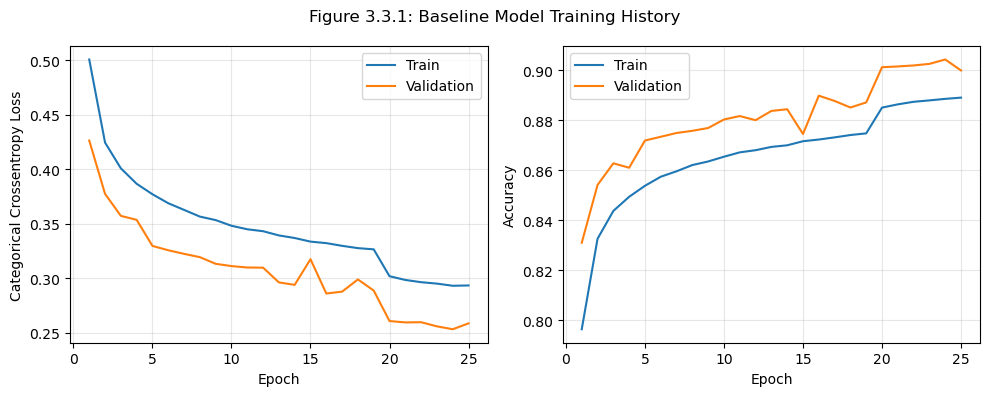

In [8]:
viz.plot_epoch_history(history, "Figure 3.3.1: Baseline Model Training History")

The trained baseline model achieves a training and validation accuracy of 89.3% and 89.4%.

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler = preprocess_data(
    df_final, scaler, label_encoder, X_numerical, response, fit_scaler=False,
)
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=3)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=3)

train_loss, train_accuracy = model.evaluate(X_train, y_train_one_hot, verbose=0)
print(f"Train accuracy: {train_accuracy:.4f}")

val_loss, val_accuracy = model.evaluate(X_val, y_val_one_hot, verbose=0)
print(f"Validation accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")


Train accuracy: 0.8930
Validation accuracy: 0.8940
Test accuracy: 0.8939


These results reinforce the findings from our EDA, which suggested that key orbital elements like inclination, eccentricity, and apogee differ meaningfully across classes, even without taking into account the time dimension of our data.

In practice, analysts often begin classification using static orbital information (which aligns with the baseline FNN model). However, when static features are ambiguous, analysts also rely on temporal patterns in the orbital data.

By neglecting time, our baseline FNN model acts as a clear benchmark for measuring how much additional accuracy can be gained by including time in our modeling. We discuss how we incorporate time in our final model in sections 4 and 5 below.

<div style='border-top:1px solid #68C1EE; border-bottom: 1px solid #68C1EE; padding: 10px'>
<h2 style='color:#147EB3'>4. Results Interpretation and Analysis <a class="anchor" id="4-results"></a></h2>
</div>

### 4.1 Baseline Model Results <a class="anchor" id="4-1-baseline-results"></a>

Our goal was to quantify how much of `TYPE` can be predicted from a state snapshot. This baseline model demonstrates that a simple feedforward neural network (FNN) already achieves nearly 90% validation accuracy, indicating that the vast majority of the predictive signal is captured by static features alone. These accuracies are consistent across the training and validation data. Figure 4.1 compares training and validation performance across different classes. The model performs similarly across object types, with rocket body classification showing a slight advantage over payload and debris.

While there are myriad methods for generating states, they can generally be thought of as aggregates of multiple types of historical data, including observations (derived from tracklets or tracks provided by the contributing sensors), recent-past states, and estimated maneuvers. Therefore, it is a promising sign that object type can be accurately predicted from a single snapshot of an object's state, because it suggests that much of the necessary discriminative information is already encoded in the static state representation—without requiring a temporal history.

However, since the time dimension is available for the majority of our objects, we aim to incorporate this component into our final model.

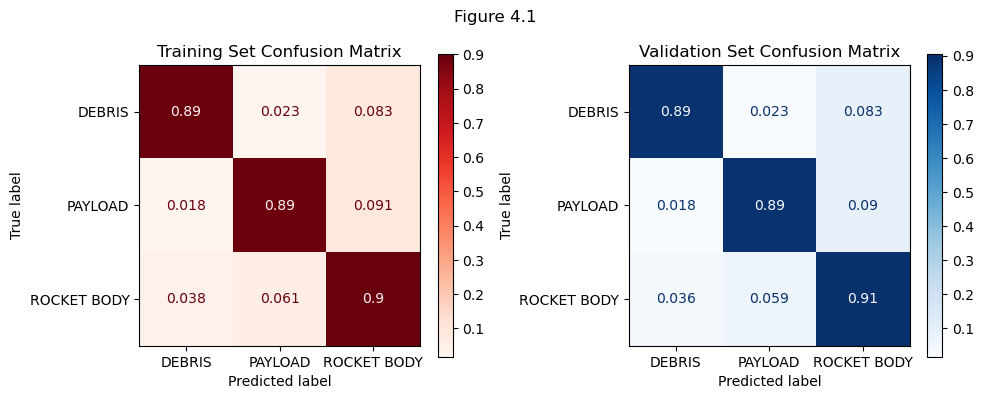

In [10]:
y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=-1)
y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=-1)
viz.plot_side_my_side_confusion("Figure 4.1", y_train, y_train_pred, "Training Set Confusion Matrix", y_val, y_val_pred, "Validation Set Confusion Matrix", label_encoder)

### 4.2 Pivot to Time-dependent Modeling <a class="anchor" id="4-2-time-modeling"></a>

Since we are now interested in the time dimension of our data, it is important to examine how states are distributed across different objects in our dataset. If objects from a particular class have more or less detailed state histories, it could significantly impact the results of our model. Figure 4.2 illustrates the distribution of state counts across the objects. Roughly half of our objects fall within the 40-49 state range. The maximum number of states any object has is 49, but only around 8.5% of objects fall into this category. If we decide against padding in our final model, we will use Figure 4.3 to decide where to draw our state-requirement threshold.

We already faced a data imbalance with rocket bodies, which we addressed using SMOTE. While this greatly improved our baseline model's performance, incorporating it into our final model will be more complex. Our SMOTE-generated states were created as stand-alone sets of orbital elements, not state histories tied to an object ID (RSO number). If the class imbalance remains a problem in our final model, we may need to downsample our data, though this is far from ideal.

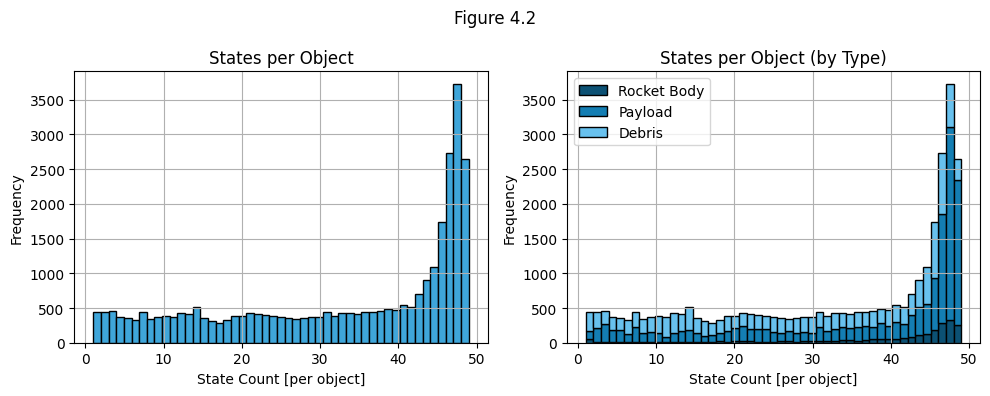

In [8]:
viz.plot_state_count_side_by_side("Figure 4.2", "States per Object","States per Object (by Type)", df_final, df_payload,df_rb,df_debris )

Figure 4.2 plots the number of states per object. We can observe that roughtly half of objects have around 40-50 states, with all three classes following a similar distribution.

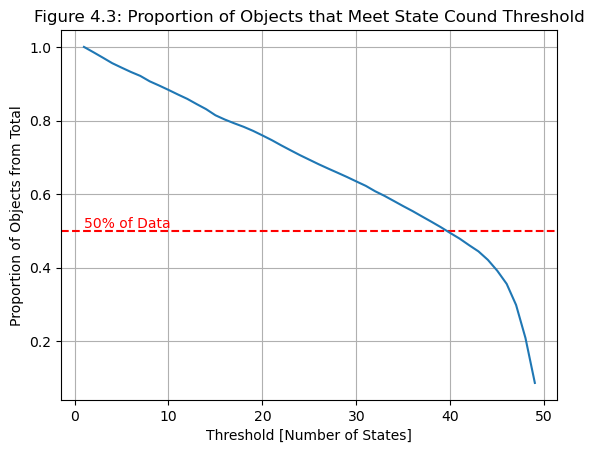

In [12]:
viz.plot_state_count_ratio('Figure 4.3: Proportion of Objects that Meet State Cound Threshold', df_final)

Figure 4.3: plots the proportion of objects in the data set that meet state-count thresholds

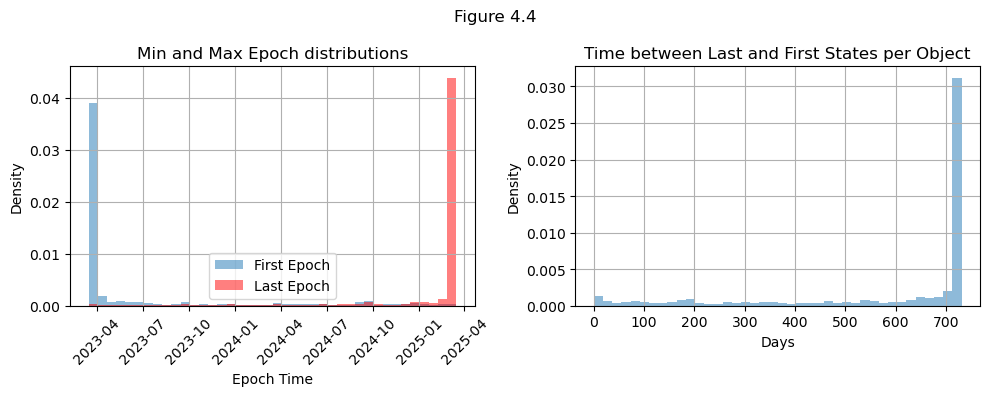

In [13]:
viz.plot_epoch_dists("Figure 4.4", 'Min and Max Epoch distributions', 'Time between Last and First States per Object', df_final);

Figure 4.4: shows the distribution of the earliest and latest timestamp of the state histories of each object in our dataset. We can see that the first epoch for most of the objects in our dataset are on 2023-03-15, while most objects have a last epoch on 2025-03-15. This makes sense, since we collected our data by querying Space-Track's API every 15 days from 2023-03-15 to 2025-03-15. Consequently, most objects have a state history that span more than 700 days. We hope that this provides a sufficient amount of state information per object to make accurate class predictions for most objects. However, it is important to note that performance of the model can suffer for objects with shallow state histories.

<div style='border-top:1px solid #68C1EE; border-bottom: 1px solid #68C1EE; padding: 10px'>
<h2 style='color:#147EB3'>5. Final Model Pipeline Setup <a class="anchor" id="5-final-model"></a></h2>
</div>

For our final model, we plan to use a method that will be similar to an ensemble machine learning technique in that there will be a second "meta" model aggregating the outputs from a previous model; however, the difference is that in the first step before the "meta" model, we will be only training a single model instead of multiple ones.

If we define $x_t^{i}$ to be the state information at given time $t$ for object $i$, our plan is to execute the training of the models in two steps:

1. use original data ($x_t^{i}$) to **train the "single state evaluation model"** and obtain outputs $\tilde{p}_t^{i}$ for the probabilities of the class of the object $i$ at given time $t$
2. use outputs from model in step 1 ($\tilde{p}_t^{i}$) + original data ($x_t^{i}$) to **aggregate the data per object** such that ($x_t^{i}$ & $\tilde{p}_t^{i}$) for all $t$ is one training data point for given object $i$ for the next model
3. use aggregated data from step 2 to **train the "per object evaluation model"**

A graphic picture of the two models is shown below -- both of them will be fully connected feed forward neural networks:

<div style='display: flex;'>
    <img src="https://tedsite.com/host/209b/Single_State_Evaluation_Model.jpg" width="400" style='margin-right: 20px;'/>
    <img src="https://tedsite.com/host/209b/Per_Object_Evaluation_Model.jpg" width='410'>
</div>


Similar to blending, we will need:

- train set to train the Single State Evaluation Model

- validation set to validate the Single State Evaluation Model and generate predictions for training the Per Object Evaluation Model

- holdout set to validate the Per Object Evaluation Model

- test set for final evaluation

Notice that when we do this split, we will need to do a split grouped by objects, such that all states for a given object fall within only one of the four sets above in order to be able to train and evaluate the Per Object Evaluation Model.

---

## References

- *ChatGPT.* OpenAI, April 2025, chatgpt.com
    - Used to help manipulate dataframe values relative to `NUMBER` grouping.
    - Used to check for grammatical errors and inconsistencies in the writeup.
- *Space-Track.org.* United States Space Force. April 2025, space-track.org

---